In [1]:
# ============================================================
#  The FAANG Autopsy
#  Returns, Risk & Diversification Analysis
# ============================================================
#  Author    : Kesidis Angelos
#  Stocks    : META, AAPL, AMZN, NFLX, GOOGL
#  Benchmark : S&P 500 (^GSPC)
#  Period    : 2018-01-01 to 2023-12-31
#  Purpose   : Log returns, risk metrics, covariance/correlation,
#              portfolio risk decomposition, benchmark comparison
# ============================================================

In [2]:
# ── IMPORTS ─────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf
 
%matplotlib inline

In [3]:
# ============================================================
# SECTION 1 — DATA COLLECTION & CLEANING
# ============================================================
 
tickers   = ["META", "AAPL", "AMZN", "NFLX", "GOOGL"]
benchmark = ["^GSPC"]
all_assets = tickers + benchmark
 
start = "2018-01-01"
end   = "2023-12-31"
 
# Download closing prices for all assets
data = yf.download(all_assets, start=start, end=end)["Close"]
 
# Basic diagnostics
print("Shape   :", data.shape)
print("Columns :", list(data.columns))
print("\n--- First 5 rows ---")
print(data.head())
print("\n--- Last 5 rows ---")
print(data.tail())
print("\n--- Missing values per column ---")
print(data.isnull().sum())

[*********************100%***********************]  6 of 6 completed

Shape   : (1509, 6)
Columns : ['AAPL', 'AMZN', 'GOOGL', 'META', 'NFLX', '^GSPC']

--- First 5 rows ---
Ticker           AAPL       AMZN      GOOGL        META       NFLX  \
Date                                                                 
2018-01-02  40.267063  59.450500  53.220631  180.007401  20.107000   
2018-01-03  40.260059  60.209999  54.128628  183.232071  20.504999   
2018-01-04  40.447067  60.479500  54.338894  182.894730  20.563000   
2018-01-05  40.907566  61.457001  55.059437  185.395126  20.999001   
2018-01-08  40.755642  62.343498  55.253826  186.813965  21.205000   

Ticker            ^GSPC  
Date                     
2018-01-02  2695.810059  
2018-01-03  2713.060059  
2018-01-04  2723.989990  
2018-01-05  2743.149902  
2018-01-08  2747.709961  

--- Last 5 rows ---
Ticker            AAPL        AMZN       GOOGL        META       NFLX  \
Date                                                                    
2023-12-22  191.433090  153.419998  140.330185  350.63836

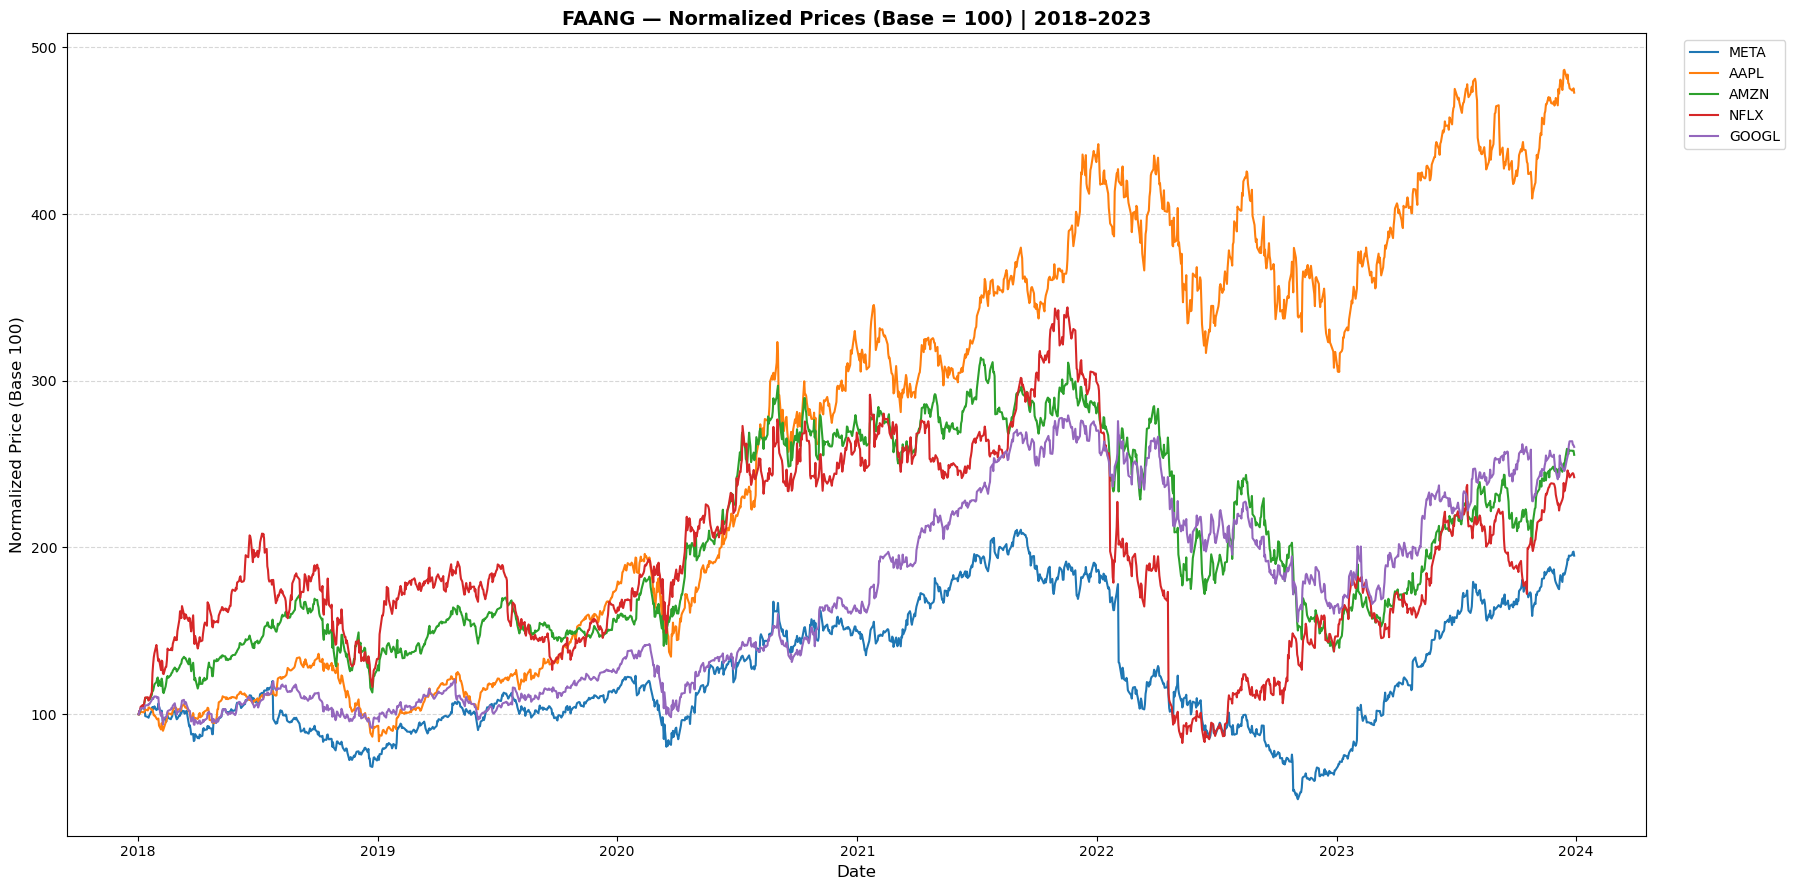

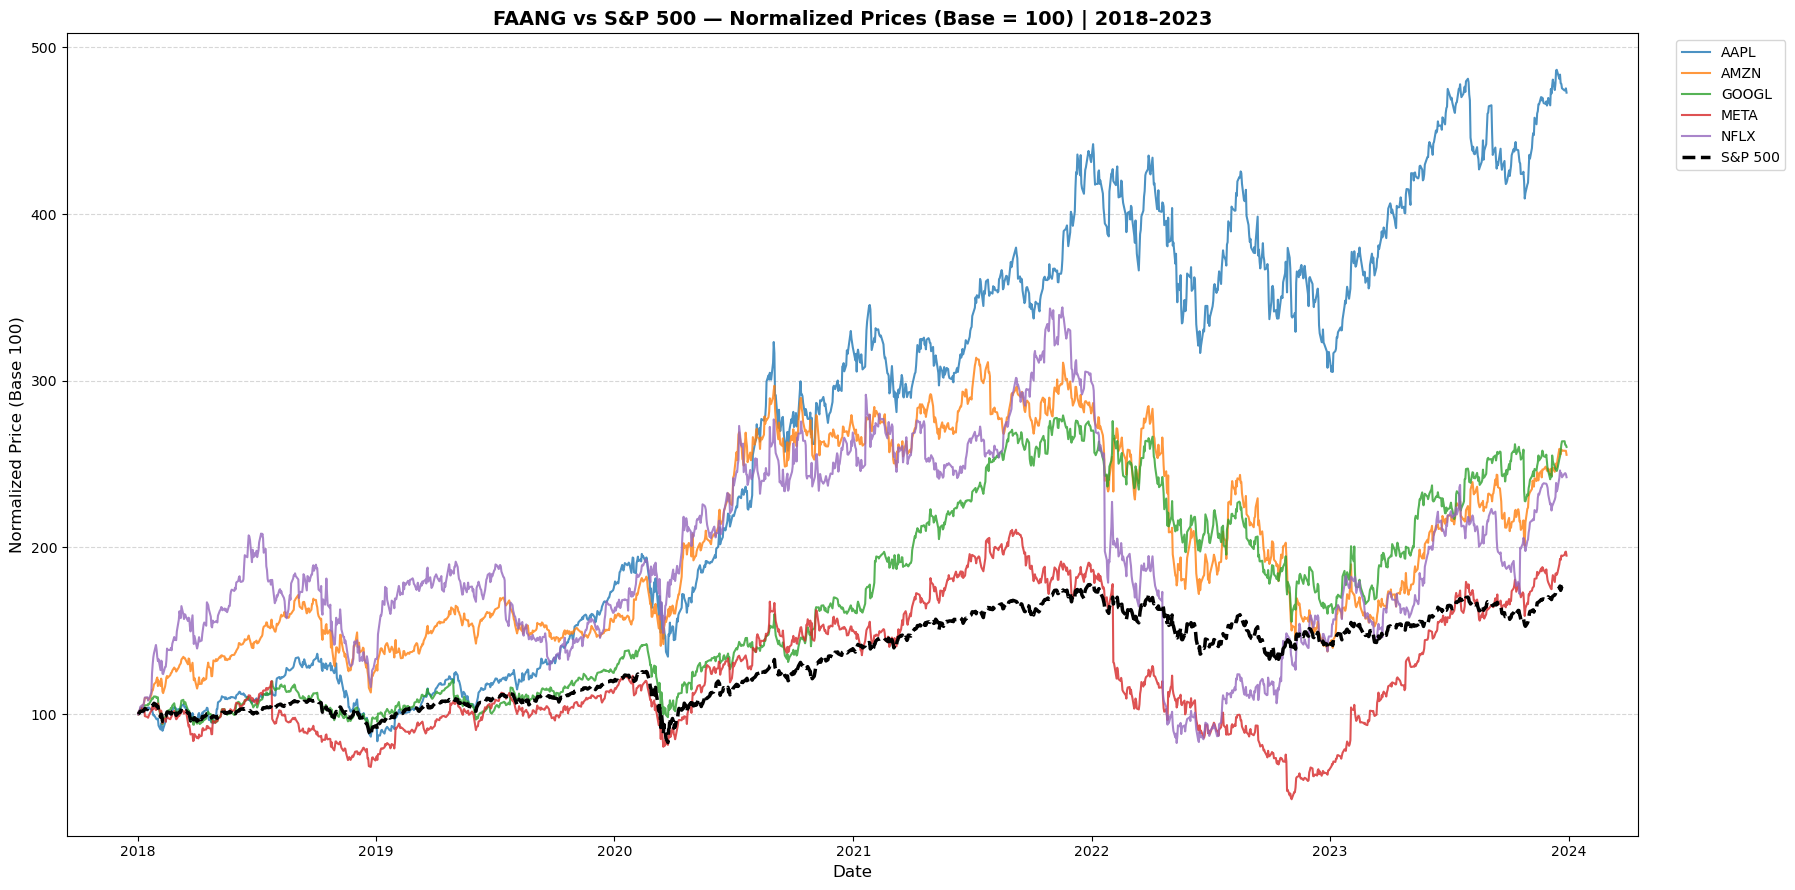

In [4]:
# ============================================================
# SECTION 2 — NORMALIZATION & VISUALIZATION
# ============================================================
 
# ── Plot 1: FAANG stocks only ────────────────────────────────
normalized_stocks = (data[tickers] / data[tickers].iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_stocks.columns:
    plt.plot(normalized_stocks[col], label=col)
 
plt.title("FAANG — Normalized Prices (Base = 100) | 2018–2023",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Plot 2: All assets — stocks + benchmark ──────────────────
normalized_all = (data / data.iloc[0]) * 100
 
plt.figure(figsize=(18, 9))
for col in normalized_all.columns:
    if col in benchmark:
        plt.plot(normalized_all[col], label="S&P 500",
                 linewidth=2.5, linestyle="--", color="black")
    else:
        plt.plot(normalized_all[col], label=col, alpha=0.8)
 
plt.title("FAANG vs S&P 500 — Normalized Prices (Base = 100) | 2018–2023",
          fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Normalized Price (Base 100)", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()


--- Daily Log Returns (first 5 rows) ---
Ticker          AAPL      AMZN     GOOGL      META      NFLX     ^GSPC
Date                                                                  
2018-01-03 -0.000174  0.012694  0.016917  0.017756  0.019601  0.006378
2018-01-04  0.004634  0.004466  0.003877 -0.001843  0.002825  0.004021
2018-01-05  0.011321  0.016033  0.013173  0.013579  0.020982  0.007009
2018-01-08 -0.003721  0.014322  0.003524  0.007624  0.009762  0.001661
2018-01-09 -0.000115  0.004665 -0.001275 -0.002180 -0.013006  0.001302


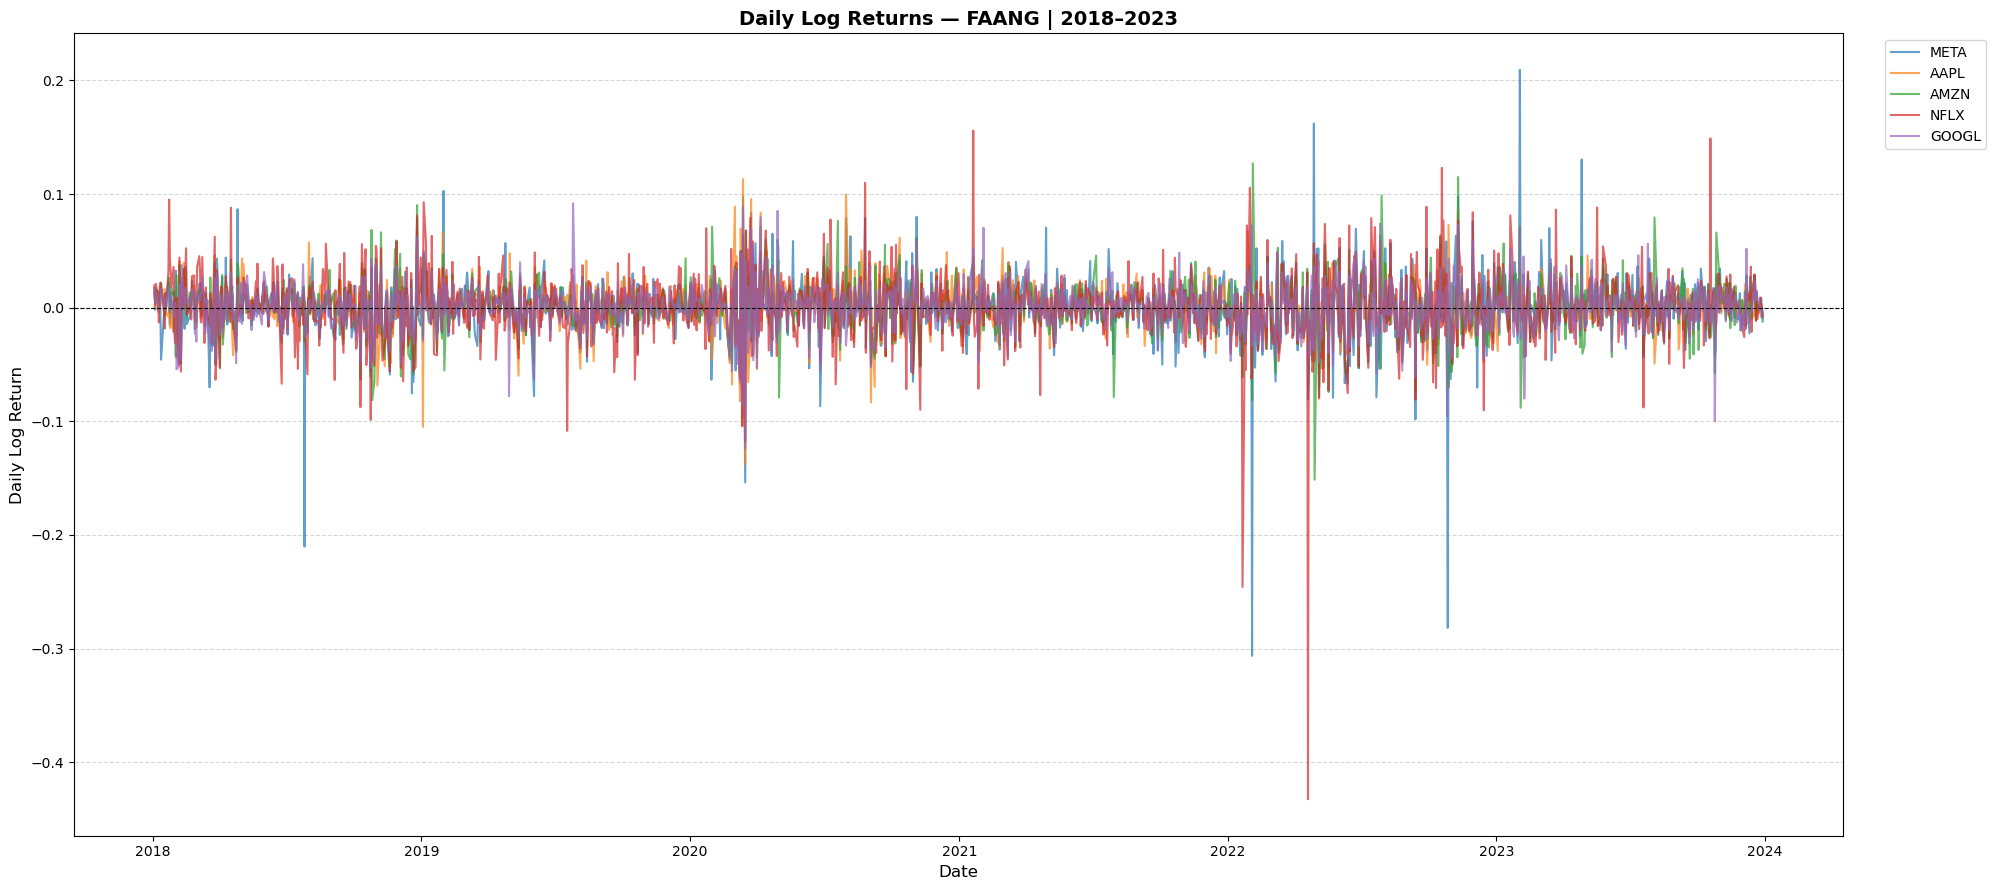


--- Individual Stock Annual Returns (Ranked) ---
       Annual Log Return (%)
Ticker                      
AAPL                  25.75%
GOOGL                 15.86%
AMZN                  15.56%
NFLX                  14.66%
META                  11.08%


In [5]:
# ============================================================
# SECTION 3 — RETURNS ANALYSIS
# ============================================================
 
# Daily log returns for all assets
log_returns = np.log(data / data.shift(1)).dropna()
 
print("\n--- Daily Log Returns (first 5 rows) ---")
print(log_returns.head())
 
# ── Plot: Daily Log Returns (FAANG only) ─────────────────────
plt.figure(figsize=(20, 9))
for col in tickers:                          # tickers only — excludes benchmark
    plt.plot(log_returns[col], label=col, alpha=0.7)
 
plt.axhline(y=0, color="black", linewidth=0.8, linestyle="--")
plt.title("Daily Log Returns — FAANG | 2018–2023", fontsize=14, fontweight="bold")
plt.xlabel("Date", fontsize=12)
plt.ylabel("Daily Log Return", fontsize=12)
plt.legend(loc="upper left", bbox_to_anchor=(1.02, 1), ncol=1, fontsize=10)
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.subplots_adjust(right=0.85)
plt.tight_layout()
plt.show()
 
# ── Annualized Returns (× 250 trading days) — stocks only ────
annual_log_returns = log_returns[tickers].mean() * 250
 
# Ranking table with % formatting
summary_returns = pd.DataFrame({
    "Annual Log Return (%)": (annual_log_returns * 100).round(2)
}).sort_values(by="Annual Log Return (%)", ascending=False)
 
summary_returns_display = summary_returns.applymap(lambda x: f"{x}%")
print("\n--- Individual Stock Annual Returns (Ranked) ---")
print(summary_returns_display.to_string())

In [6]:
# ============================================================
# SECTION 4 — RISK ANALYSIS
# ============================================================
 
# Annual Std Dev and Variance — stocks only
annual_std_dev = log_returns[tickers].std() * (250 ** 0.5)
annual_variance = log_returns[tickers].var() * 250
 
# Risk ranking table — lowest to highest risk
risk_table = pd.DataFrame({
    "Annual Std Dev (%)":  (annual_std_dev  * 100).round(2),
    "Annual Variance (%)": (annual_variance * 100).round(2)
}).sort_values(by="Annual Std Dev (%)", ascending=True)
 
risk_table_display = risk_table.applymap(lambda x: f"{x}%")
print("\n--- Risk Analysis — Ranked Low to High ---")
print(risk_table_display.to_string())


--- Risk Analysis — Ranked Low to High ---
       Annual Std Dev (%) Annual Variance (%)
Ticker                                       
GOOGL              31.14%                9.7%
AAPL               31.57%               9.97%
AMZN               35.23%              12.41%
META               43.29%              18.74%
NFLX               47.14%              22.22%



--- Annual Covariance Matrix ---
Ticker      META      AAPL      AMZN      NFLX     GOOGL
Ticker                                                  
META    0.187402  0.077322  0.092008  0.100170  0.088534
AAPL    0.077322  0.099653  0.069529  0.069616  0.066544
AMZN    0.092008  0.069529  0.124102  0.095345  0.073827
NFLX    0.100170  0.069616  0.095345  0.222201  0.070909
GOOGL   0.088534  0.066544  0.073827  0.070909  0.096982

--- Correlation Matrix ---
Ticker   META   AAPL   AMZN   NFLX  GOOGL
Ticker                                   
META    1.000  0.566  0.603  0.491  0.657
AAPL    0.566  1.000  0.625  0.468  0.677
AMZN    0.603  0.625  1.000  0.574  0.673
NFLX    0.491  0.468  0.574  1.000  0.483
GOOGL   0.657  0.677  0.673  0.483  1.000

Diagonal check (must all be 1.0): [1. 1. 1. 1. 1.]

Average Pairwise Correlation: 0.582
Observation: High avg correlation → limited diversification benefit within FAANG


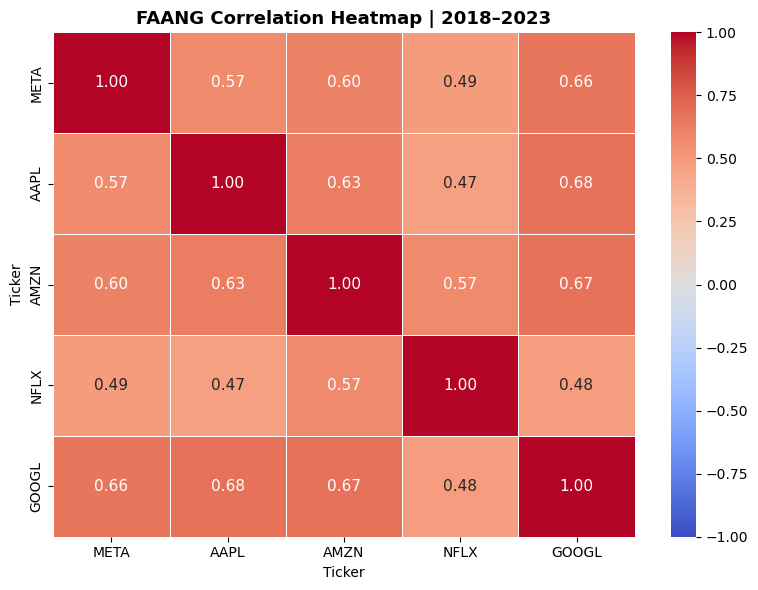

In [7]:
# ============================================================
# SECTION 5 — COVARIANCE & CORRELATION
# ============================================================
 
# Covariance matrix — annualized (× 250)
cov_matrix = log_returns[tickers].cov() * 250
print("\n--- Annual Covariance Matrix ---")
print(cov_matrix.round(6))
 
# Correlation matrix — never annualized
corr_matrix = log_returns[tickers].corr()
print("\n--- Correlation Matrix ---")
print(corr_matrix.round(3))
print("\nDiagonal check (must all be 1.0):", np.diag(corr_matrix.values).round(3))
 
# Average pairwise correlation (excluding diagonal)
mask = np.ones(corr_matrix.shape, dtype=bool)
np.fill_diagonal(mask, False)
avg_corr = corr_matrix.values[mask].mean()
print(f"\nAverage Pairwise Correlation: {round(avg_corr, 3)}")
print("Observation: High avg correlation → limited diversification benefit within FAANG")
 
# ── Correlation Heatmap ───────────────────────────────────────
plt.figure(figsize=(8, 6))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1, vmax=1,
    annot_kws={"size": 11}
)
plt.title("FAANG Correlation Heatmap | 2018–2023", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [8]:
# ============================================================
# SECTION 6 — PORTFOLIO RISK
# ============================================================
 
# Equal-weight portfolio
n = len(tickers)
weights = np.array([1 / n] * n)
 
print(f"\nNumber of stocks : {n}")
print(f"Weight per stock : {round(weights[0], 6)}")
print(f"Sum of weights   : {round(sum(weights), 10)}")   # must equal 1.0
 
# Portfolio Variance and Volatility — matrix form: w^T · Σ · w
portfolio_variance   = np.dot(weights.T, np.dot(cov_matrix, weights))
portfolio_volatility = portfolio_variance ** 0.5
 
print("\n===== Portfolio Variance & Volatility =====")
print(f"Portfolio Variance   : {portfolio_variance:.6f}")
print(f"Portfolio Volatility : {round(portfolio_volatility * 100, 2)}%")
 
# ── Systematic vs Diversifiable Risk ─────────────────────────
# Systematic Risk: sum of (w_i^2 * variance_i) — no diversification
sr = np.sum(weights ** 2 * annual_variance[tickers].values)
 
# Diversifiable Risk: what correlation eliminates
dr = portfolio_variance - sr
 
# Worst-case variance: if all assets were perfectly correlated (ρ = 1)
worst_case_variance = (np.sum(weights * np.sqrt(annual_variance[tickers].values))) ** 2
diversification_benefit = worst_case_variance - portfolio_variance
diversification_ratio   = (diversification_benefit / worst_case_variance) * 100
 
print("\n===== Risk Decomposition =====")
print(f"Systematic Risk (SR)         : {round(sr * 100, 4)}%")
print(f"Diversifiable Risk (DR)      : {round(dr * 100, 4)}%")
print(f"Verification SR + DR         : {round((sr + dr) * 100, 4)}%  (= Portfolio Variance ✓)")
print(f"\nWorst-Case Variance (ρ=1)    : {worst_case_variance:.6f}")
print(f"Actual Portfolio Variance    : {portfolio_variance:.6f}")
print(f"Diversification Benefit      : {diversification_benefit:.6f}")
print(f"Diversification Ratio        : {round(diversification_ratio, 1)}%  (% of risk removed by diversification)")


Number of stocks : 5
Weight per stock : 0.2
Sum of weights   : 1.0

===== Portfolio Variance & Volatility =====
Portfolio Variance   : 0.093518
Portfolio Volatility : 30.58%

===== Risk Decomposition =====
Systematic Risk (SR)         : 2.9214%
Diversifiable Risk (DR)      : 6.4304%
Verification SR + DR         : 9.3518%  (= Portfolio Variance ✓)

Worst-Case Variance (ρ=1)    : 0.141927
Actual Portfolio Variance    : 0.093518
Diversification Benefit      : 0.048409
Diversification Ratio        : 34.1%  (% of risk removed by diversification)



FAANG Portfolio Annual Return (Equal-Weight): 16.58%

===== Portfolio vs S&P 500 =====
          Asset  Annual Return (%)  Volatility (%)
FAANG Portfolio              16.58           30.58
        S&P 500               9.46           20.67


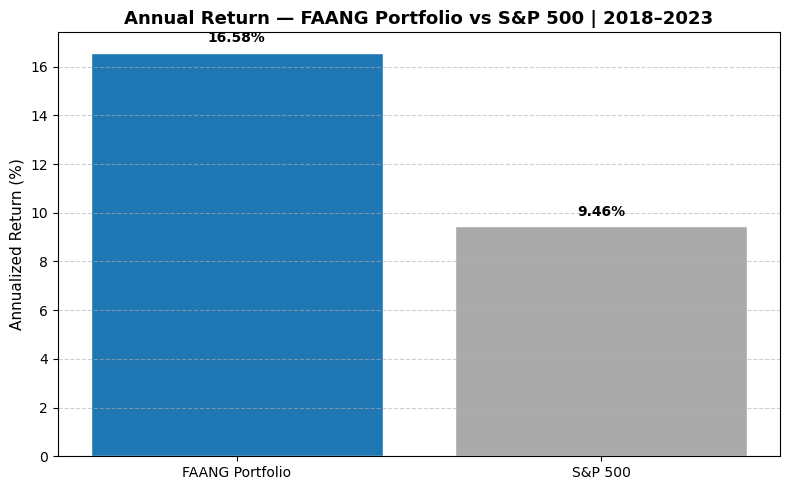

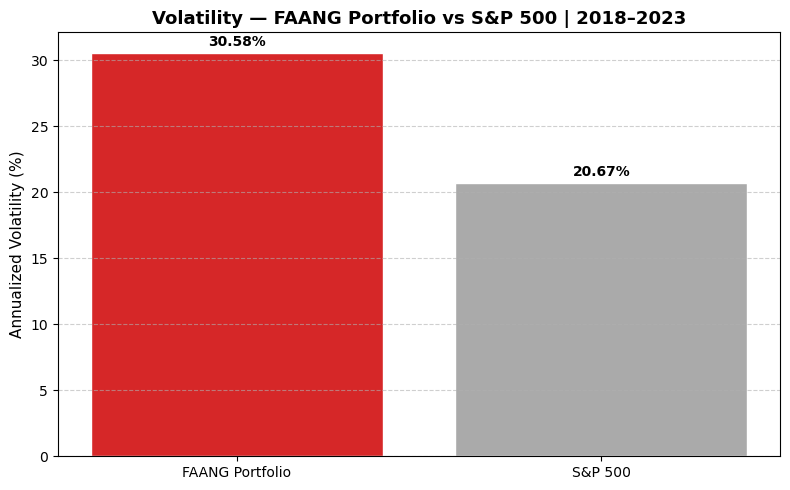

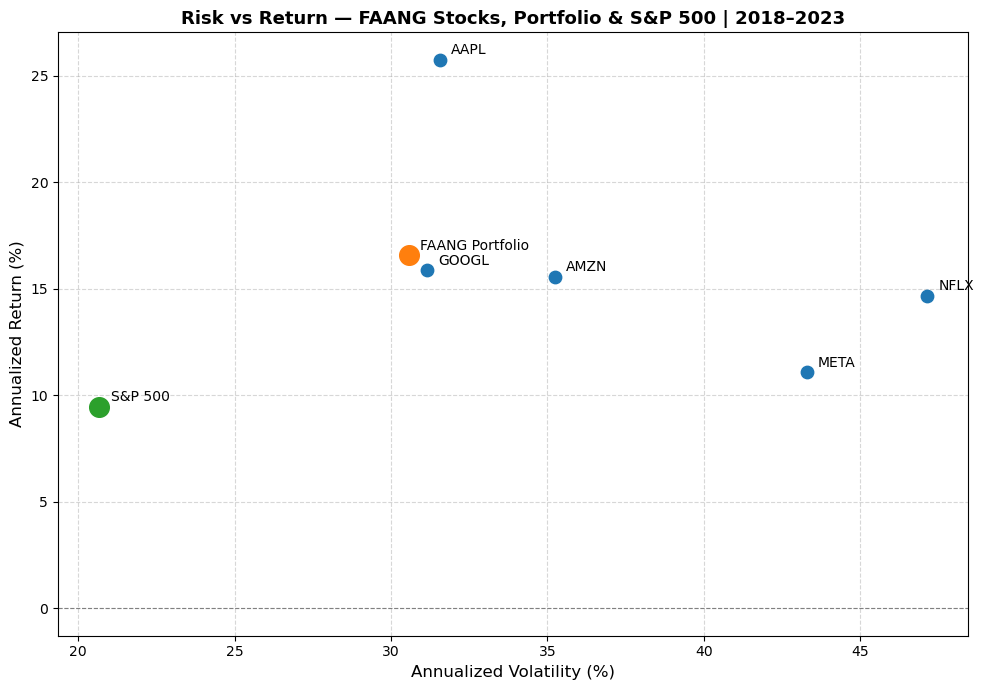

In [9]:
# ============================================================
# SECTION 7 — PORTFOLIO RETURN vs RISK
# ============================================================
 
# Portfolio annual return
portfolio_return = np.dot(annual_log_returns[tickers], weights)
print(f"\nFAANG Portfolio Annual Return (Equal-Weight): {round(portfolio_return * 100, 2)}%")
 
# Benchmark metrics
spx_annual_return     = log_returns["^GSPC"].mean() * 250
spx_annual_volatility = log_returns["^GSPC"].std()  * (250 ** 0.5)
 
# ── Comparison Table ──────────────────────────────────────────
comparison_df = pd.DataFrame({
    "Asset":             ["FAANG Portfolio", "S&P 500"],
    "Annual Return (%)": [round(portfolio_return * 100, 2),
                          round(spx_annual_return * 100, 2)],
    "Volatility (%)":    [round(portfolio_volatility * 100, 2),
                          round(spx_annual_volatility * 100, 2)]
})
 
print("\n===== Portfolio vs S&P 500 =====")
print(comparison_df.to_string(index=False))
 
# ── Bar Chart: Returns ────────────────────────────────────────
colors_ret = ["#1f77b4", "#AAAAAA"]
 
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["Asset"], comparison_df["Annual Return (%)"],
               color=colors_ret, edgecolor="white")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.3,
             f"{yval}%", ha="center", va="bottom", fontweight="bold")
plt.title("Annual Return — FAANG Portfolio vs S&P 500 | 2018–2023",
          fontsize=13, fontweight="bold")
plt.ylabel("Annualized Return (%)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
 
# ── Bar Chart: Volatility ─────────────────────────────────────
colors_vol = ["#d62728", "#AAAAAA"]
 
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["Asset"], comparison_df["Volatility (%)"],
               color=colors_vol, edgecolor="white")
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, yval + 0.3,
             f"{yval}%", ha="center", va="bottom", fontweight="bold")
plt.title("Volatility — FAANG Portfolio vs S&P 500 | 2018–2023",
          fontsize=13, fontweight="bold")
plt.ylabel("Annualized Volatility (%)", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()
 
# ── Scatter Plot: Risk vs Return (every asset + portfolio + S&P 500) ──
all_returns = list(annual_log_returns[tickers].values) + [portfolio_return, spx_annual_return]
all_vols    = list(annual_std_dev[tickers].values)     + [portfolio_volatility, spx_annual_volatility]
all_labels  = tickers + ["FAANG Portfolio", "S&P 500"]
all_colors  = ["#1f77b4"] * 5 + ["#ff7f0e", "#2ca02c"]
all_sizes   = [80] * 5 + [200, 200]
 
plt.figure(figsize=(10, 7))
for i, label in enumerate(all_labels):
    plt.scatter(all_vols[i] * 100, all_returns[i] * 100,
                color=all_colors[i], s=all_sizes[i], zorder=5)
    plt.annotate(label,
                 (all_vols[i] * 100, all_returns[i] * 100),
                 textcoords="offset points", xytext=(8, 4), fontsize=10)
 
plt.axhline(y=0, color="gray", linewidth=0.8, linestyle="--")
plt.title("Risk vs Return — FAANG Stocks, Portfolio & S&P 500 | 2018–2023",
          fontsize=13, fontweight="bold")
plt.xlabel("Annualized Volatility (%)", fontsize=12)
plt.ylabel("Annualized Return (%)", fontsize=12)
plt.grid(linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# SECTION 8 — CONCLUSIONS
# ============================================================
 
alpha = round((portfolio_return - spx_annual_return) * 100, 2)
extra_vol = round((portfolio_volatility - spx_annual_volatility) * 100, 2)
 
print("=" * 60)
print("  CONCLUSIONS — The FAANG Autopsy")
print("=" * 60)
print(f"\n  FAANG Portfolio Annual Return : {round(portfolio_return * 100, 2)}%")
print(f"  S&P 500 Annual Return         : {round(spx_annual_return * 100, 2)}%")
print(f"  Alpha vs S&P 500              : {'+' if alpha > 0 else ''}{alpha}%")
print(f"\n  FAANG Portfolio Volatility    : {round(portfolio_volatility * 100, 2)}%")
print(f"  S&P 500 Volatility            : {round(spx_annual_volatility * 100, 2)}%")
print(f"  Extra Volatility vs S&P 500   : {'+' if extra_vol > 0 else ''}{extra_vol}%")
print(f"\n  Avg Pairwise Correlation      : {round(avg_corr, 3)}")
print(f"  Diversification Ratio         : {round(diversification_ratio, 1)}%")
print("\n  Key Observations:")
print("  1. The FAANG portfolio generated higher returns than the S&P 500,")
print("     but at the cost of significantly higher volatility.")
print("  2. Average pairwise correlation is high — all five stocks tend to")
print("     move together, limiting the true diversification benefit.")
print("  3. The low Diversification Ratio confirms that FAANG is effectively")
print("     a concentrated tech bet, not a diversified portfolio.")
print("  4. On the Risk vs Return scatter, FAANG stocks cluster in the")
print("     high-risk / high-return quadrant — consistent with growth investing.")
print("  5. Conclusion: FAANG outperforms the S&P 500 in returns, but an")
print("     investor takes on concentrated sector risk to achieve it.")
print("     For a truly diversified portfolio, non-tech assets are essential.")
print("=" * 60)

  CONCLUSIONS — The FAANG Autopsy

  FAANG Portfolio Annual Return : 16.58%
  S&P 500 Annual Return         : 9.46%
  Alpha vs S&P 500              : +7.12%

  FAANG Portfolio Volatility    : 30.58%
  S&P 500 Volatility            : 20.67%
  Extra Volatility vs S&P 500   : +9.91%

  Avg Pairwise Correlation      : 0.582
  Diversification Ratio         : 34.1%

  Key Observations:
  1. The FAANG portfolio generated higher returns than the S&P 500,
     but at the cost of significantly higher volatility.
  2. Average pairwise correlation is high — all five stocks tend to
     move together, limiting the true diversification benefit.
  3. The low Diversification Ratio confirms that FAANG is effectively
     a concentrated tech bet, not a diversified portfolio.
  4. On the Risk vs Return scatter, FAANG stocks cluster in the
     high-risk / high-return quadrant — consistent with growth investing.
  5. Conclusion: FAANG outperforms the S&P 500 in returns, but an
     investor takes on conce